# DAC Latent Explorer
This notebook loads a DAC latent `.pt` file and provides utilities to inspect, visualize, analyze, reconstruct, and play audio from the latents.

**How to use**
1. Update the `LATENT_PATH` in the next cell (or use the file picker if available).
2. Run cells top-to-bottom.
3. If a DAC decoder is available in the repo, use the reconstruction cells to listen to audio.

## 1. Import Required Libraries
Imports for loading tensors, visualization, and audio playback.

In [1]:
import os
import json
import math
import warnings
from pathlib import Path

import numpy as np

try:
    import torch
except Exception as e:
    raise RuntimeError("PyTorch is required to load .pt files.") from e

import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Optional dependencies
try:
    import scipy
except Exception:
    scipy = None

try:
    import ipywidgets as widgets
    from ipywidgets import interact
except Exception:
    widgets = None
    interact = None

plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=UserWarning)

## 2. Load DAC Latent File
Set the path to your `.pt` file and load it. The loader will attempt to extract the latent tensor and any related metadata.

In [2]:
# --- File selection ---
LATENT_PATH = r"C:\Users\Dhanuja\Desktop\Vibeshift\VibeShift\data\latent_data\latent_classical\00001_Preludes Book 2 - La puerta del Vino.pt"  

def pick_file():
    """Open a file picker (best-effort)."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk()
        root.withdraw()
        return filedialog.askopenfilename(filetypes=[("PyTorch", "*.pt"), ("All", "*.*")])
    except Exception:
        return ""

if not LATENT_PATH:
    chosen = pick_file()
    if chosen:
        LATENT_PATH = chosen

def _find_first_tensor(obj, prefix=""):
    """Return (tensor, keypath) if any tensor found within obj."""
    if torch.is_tensor(obj):
        return obj, prefix or "<root>"
    if isinstance(obj, dict):
        for k, v in obj.items():
            t, kp = _find_first_tensor(v, prefix=f"{prefix}.{k}" if prefix else str(k))
            if t is not None:
                return t, kp
    if isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            t, kp = _find_first_tensor(v, prefix=f"{prefix}[{i}]" if prefix else f"[{i}]")
            if t is not None:
                return t, kp
    return None, None

def load_latent(path):
    if not path:
        raise ValueError("LATENT_PATH is empty.")
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    obj = torch.load(path, map_location="cpu")
    tensor, keypath = _find_first_tensor(obj)
    info = {
        "path": str(path),
        "type": type(obj).__name__,
        "tensor_keypath": keypath,
    }
    return obj, tensor, info

latent_obj, latent_tensor, latent_info = load_latent(LATENT_PATH)
latent_info

{'path': 'C:\\Users\\Dhanuja\\Desktop\\Vibeshift\\VibeShift\\data\\latent_data\\latent_classical\\00001_Preludes Book 2 - La puerta del Vino.pt',
 'type': 'dict',
 'tensor_keypath': 'z'}

## 3. Inspect Latent Tensor Properties
Detailed inspection of shape, dtype, device, and numerical statistics.

In [3]:
def summarize_tensor(t):
    if t is None:
        return "No tensor found."
    t_cpu = t.detach().cpu()
    t_float = t_cpu.float()
    nan_count = torch.isnan(t_float).sum().item()
    inf_count = torch.isinf(t_float).sum().item()
    return {
        "shape": tuple(t_cpu.shape),
        "dtype": str(t_cpu.dtype),
        "device": str(t.device),
        "min": float(t_float.min().item()),
        "max": float(t_float.max().item()),
        "mean": float(t_float.mean().item()),
        "std": float(t_float.std().item()),
        "nan_count": int(nan_count),
        "inf_count": int(inf_count),
    }

summary = summarize_tensor(latent_tensor)
summary

{'shape': (1, 2585, 1024),
 'dtype': 'torch.float32',
 'device': 'cpu',
 'min': -18.571083068847656,
 'max': 18.74863052368164,
 'mean': 0.04897201061248779,
 'std': 3.5924580097198486,
 'nan_count': 0,
 'inf_count': 0}

In [4]:
def summarize_object(obj, max_items=20):
    if isinstance(obj, dict):
        items = list(obj.items())[:max_items]
        return {k: type(v).__name__ for k, v in items}
    if isinstance(obj, (list, tuple)):
        return [type(v).__name__ for v in obj[:max_items]]
    return type(obj).__name__

summarize_object(latent_obj)

{'z': 'Tensor',
 'codes': 'Tensor',
 'latents': 'Tensor',
 'sample_rate': 'int',
 'original_length': 'int'}

## 4. Visualize Latent Representations
Heatmaps and time-series views for different channels and time slices.

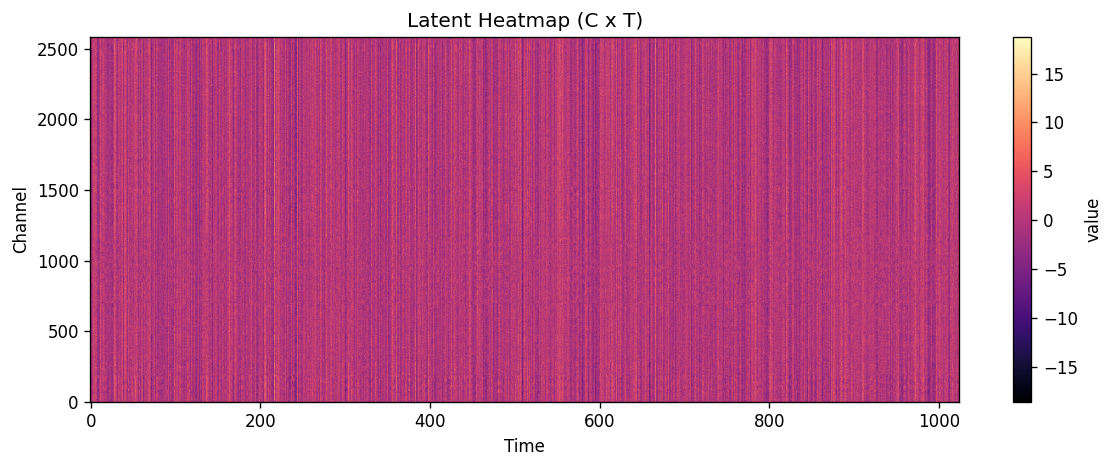

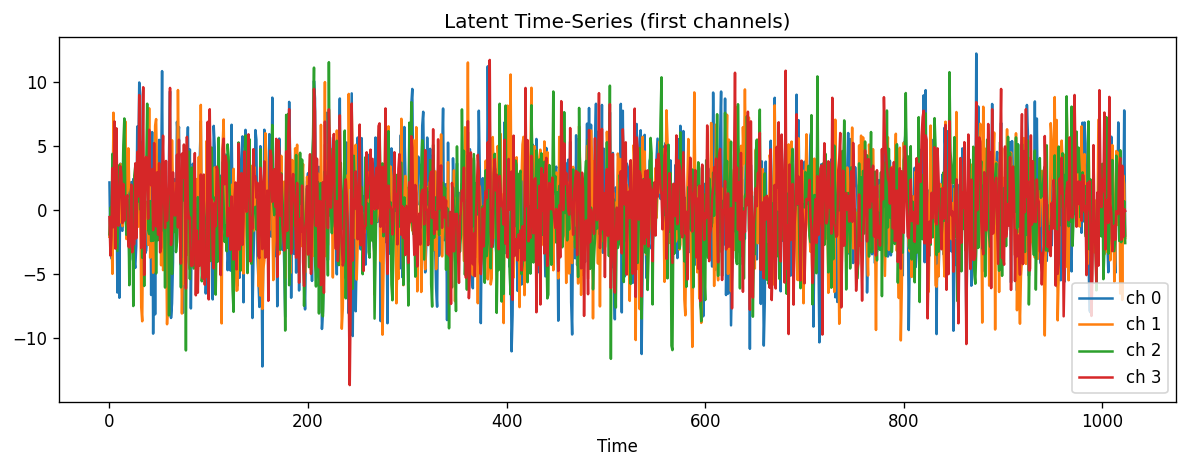

In [5]:
def to_channel_time(t):
    """Return a 2D (C, T) view for visualization."""
    if t is None:
        return None
    x = t.detach().cpu()
    if x.ndim == 1:
        return x.unsqueeze(0)
    if x.ndim == 2:
        # Heuristic: treat smaller dim as channels if very small
        c, tdim = x.shape
        if c <= 32 or c < tdim:
            return x
        return x.T
    if x.ndim == 3:
        # Assume (B, C, T) or (C, T, B)
        if x.shape[0] <= 8:  # batch small
            return x[0]
        if x.shape[1] <= 64:
            return x[:, :, 0]
        return x[0]
    # Flatten higher dims into channels
    flat = x.reshape(x.shape[0], -1)
    return flat

ct = to_channel_time(latent_tensor)
ct is not None and ct.shape

if ct is not None:
    plt.figure(figsize=(10, 4))
    plt.imshow(ct, aspect='auto', origin='lower', cmap='magma')
    plt.colorbar(label='value')
    plt.title('Latent Heatmap (C x T)')
    plt.xlabel('Time')
    plt.ylabel('Channel')
    plt.tight_layout()
    plt.show()

    # Time-series for a few channels
    n_ch = min(4, ct.shape[0])
    plt.figure(figsize=(10, 4))
    for i in range(n_ch):
        plt.plot(ct[i].numpy(), label=f'ch {i}')
    plt.title('Latent Time-Series (first channels)')
    plt.xlabel('Time')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 5. Extract and Analyze Statistics
Compute distribution and per-channel statistics.

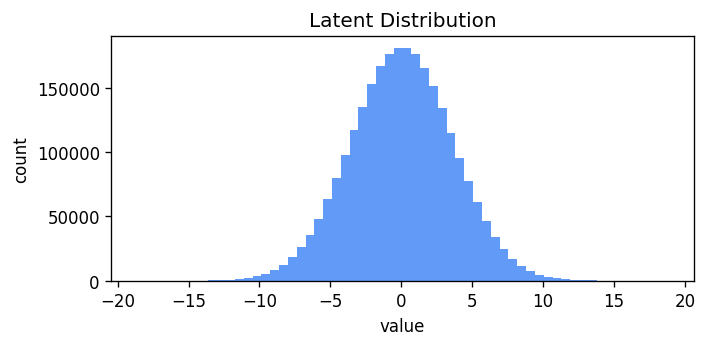

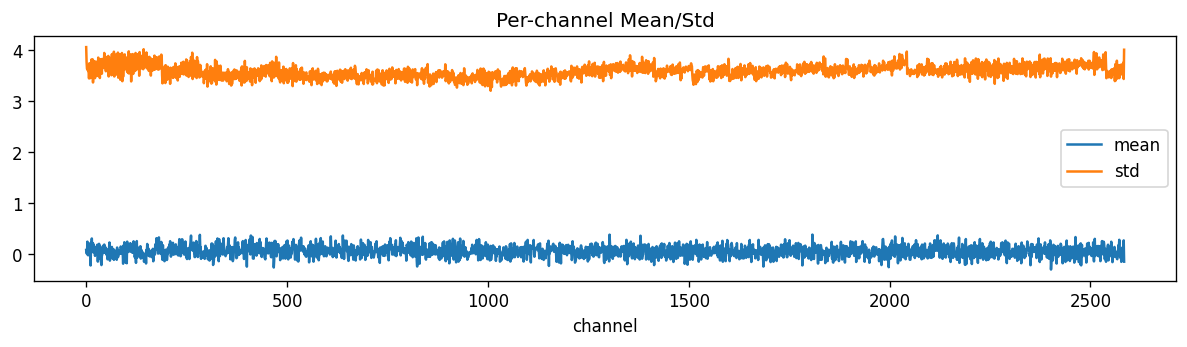

In [6]:
if ct is not None:
    flat = ct.flatten().numpy()
    plt.figure(figsize=(6, 3))
    plt.hist(flat, bins=60, color='#3b82f6', alpha=0.8)
    plt.title('Latent Distribution')
    plt.xlabel('value')
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()

    # Per-channel stats
    ch_mean = ct.mean(dim=1).numpy()
    ch_std = ct.std(dim=1).numpy()
    plt.figure(figsize=(10, 3))
    plt.plot(ch_mean, label='mean')
    plt.plot(ch_std, label='std')
    plt.title('Per-channel Mean/Std')
    plt.xlabel('channel')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. Reconstruct Audio from Latents
Attempt to decode latents to audio if a DAC decoder is available. If you have a specific decoder or checkpoint, set it below.

In [7]:
DAC_MODEL_PATH = None  # optional: path to a DAC checkpoint if required
DEVICE = "cpu"

def try_get_sample_rate(obj):
    if isinstance(obj, dict):
        for k in ["sr", "sample_rate", "sampling_rate", "rate"]:
            if k in obj and isinstance(obj[k], (int, float)):
                return int(obj[k])
    return None

def load_dac_decoder(model_path=None, device="cpu"):
    """Best-effort DAC decoder loader."""
    # Try local utility module
    try:
        from utills import dac as dac_util
        if hasattr(dac_util, "load_model"):
            return dac_util.load_model(model_path, device=device)
        if hasattr(dac_util, "DAC"):
            model = dac_util.DAC()
            if model_path:
                state = torch.load(model_path, map_location=device)
                if isinstance(state, dict) and "state_dict" in state:
                    model.load_state_dict(state["state_dict"], strict=False)
                else:
                    model.load_state_dict(state, strict=False)
            model.to(device)
            model.eval()
            return model
    except Exception:
        pass

    # Try external 'dac' package
    try:
        import dac
        if hasattr(dac, "model") and hasattr(dac.model, "DAC"):
            model = dac.model.DAC()
            if model_path:
                state = torch.load(model_path, map_location=device)
                if isinstance(state, dict) and "state_dict" in state:
                    model.load_state_dict(state["state_dict"], strict=False)
                else:
                    model.load_state_dict(state, strict=False)
            model.to(device)
            model.eval()
            return model
    except Exception:
        pass

    return None

def decode_latents(model, latents):
    if model is None or latents is None:
        return None
    with torch.no_grad():
        x = latents.to(next(model.parameters()).device) if hasattr(model, "parameters") else latents
        if hasattr(model, "decode"):
            y = model.decode(x)
        elif hasattr(model, "decoder"):
            y = model.decoder(x)
        elif callable(model):
            y = model(x)
        else:
            return None
    if isinstance(y, (list, tuple)):
        y = y[0]
    return y.detach().cpu().squeeze()

decoder = load_dac_decoder(DAC_MODEL_PATH, device=DEVICE)
recon_audio = decode_latents(decoder, latent_tensor)
sample_rate = try_get_sample_rate(latent_obj) or 44100
{"decoder_loaded": decoder is not None, "sample_rate": sample_rate, "recon_audio_shape": None if recon_audio is None else tuple(recon_audio.shape)}

RuntimeError: Given groups=1, weight of size [1536, 1024, 7], expected input[1, 2585, 1024] to have 1024 channels, but got 2585 channels instead

## 7. Interactive Playback Utilities
Playback for reconstructed audio and any original waveform found in the file.

In [ ]:
def _find_audio_array(obj):
    if torch.is_tensor(obj):
        if obj.ndim in (1, 2):
            return obj
    if isinstance(obj, np.ndarray):
        if obj.ndim in (1, 2):
            return obj
    if isinstance(obj, dict):
        for k in ["audio", "wav", "waveform", "x", "y"]:
            if k in obj:
                return _find_audio_array(obj[k])
        for v in obj.values():
            a = _find_audio_array(v)
            if a is not None:
                return a
    if isinstance(obj, (list, tuple)):
        for v in obj:
            a = _find_audio_array(v)
            if a is not None:
                return a
    return None

orig_audio = _find_audio_array(latent_obj)
if orig_audio is not None and torch.is_tensor(orig_audio):
    orig_audio = orig_audio.detach().cpu().squeeze().numpy()
elif isinstance(orig_audio, np.ndarray):
    orig_audio = orig_audio.squeeze()

if recon_audio is not None:
    display(Audio(recon_audio.numpy() if torch.is_tensor(recon_audio) else recon_audio, rate=sample_rate))
else:
    print("No reconstructed audio available.")

if orig_audio is not None:
    display(Audio(orig_audio, rate=sample_rate))
else:
    print("No original audio found in file.")

## 8. Latent Interpolation and Manipulation
Interpolate between two latents and optionally decode the result.

In [ ]:
LATENT_PATH_B = r""  # optional: another .pt file
latent_tensor_b = None
if LATENT_PATH_B:
    _, latent_tensor_b, _ = load_latent(LATENT_PATH_B)

def interpolate_latents(a, b, alpha=0.5):
    if a is None or b is None:
        return None
    if a.shape != b.shape:
        raise ValueError("Latent shapes must match for interpolation.")
    return (1 - alpha) * a + alpha * b

alpha = 0.5
latent_interp = interpolate_latents(latent_tensor, latent_tensor_b, alpha)
if latent_interp is not None:
    ct_i = to_channel_time(latent_interp)
    plt.figure(figsize=(10, 4))
    plt.imshow(ct_i, aspect='auto', origin='lower', cmap='magma')
    plt.title(f'Interpolated Latent Heatmap (alpha={alpha})')
    plt.tight_layout()
    plt.show()

    interp_audio = decode_latents(decoder, latent_interp)
    if interp_audio is not None:
        display(Audio(interp_audio.numpy() if torch.is_tensor(interp_audio) else interp_audio, rate=sample_rate))
else:
    print("Set LATENT_PATH_B to enable interpolation.")